# Differenz between row-Data and Normalize-Data:

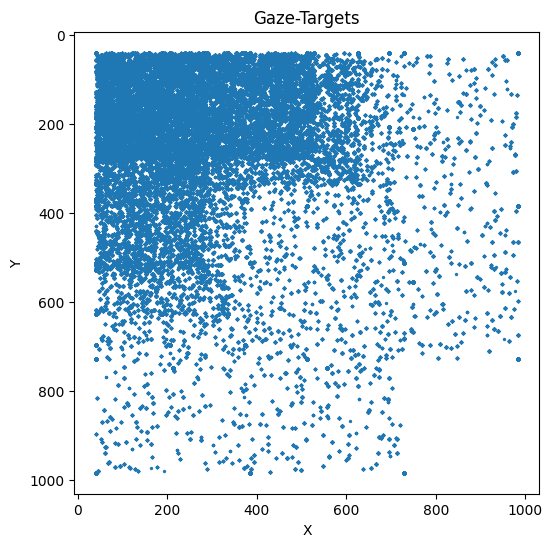



X_min: 0.0390625	 X_max: 1.0
Y_min: 0.0390625	 Y_max: 1.0 




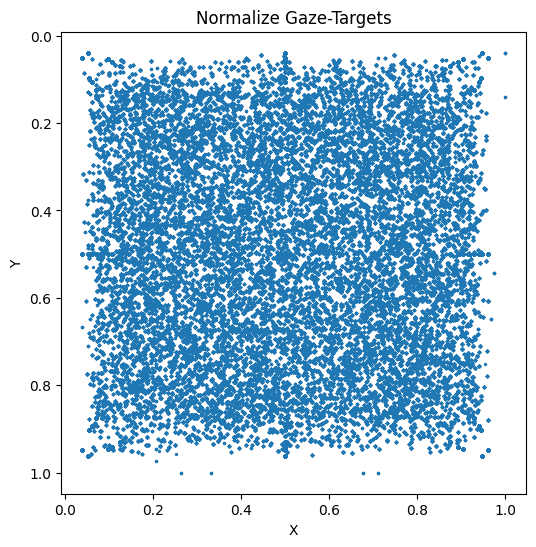

In [37]:
# PLOT:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



labels_file = "./dataset/labels.csv"

df = pd.read_csv(labels_file)

# print(df.head())
# print("Anzahl Samples:", len(df))

x = df["x"]
y = df["y"]

# print(f"X_min: {np.min(x)}\t X_max: {np.max(x)}")
# print(f"Y_min: {np.min(y)}\t Y_max: {np.max(y)}")

plt.figure(figsize=(6,6))
plt.scatter(x, y, s=2)

plt.title("Gaze-Targets")
plt.xlabel("X")
plt.ylabel("Y")

plt.gca().invert_yaxis()
plt.show()





# Normalize:

norm_labels_file = './dataset/norm_labels.csv'

df2 = pd.read_csv(norm_labels_file)

x = df2["x"]
y = df2["y"]

print(f"\n\nX_min: {np.min(x)}\t X_max: {np.max(x)}")
print(f"Y_min: {np.min(y)}\t Y_max: {np.max(y)} \n\n")
"""
df = pd.read_csv("./dataset/norm_labels.csv")

errors = df[(df["x_norm"] > 1) | (df["y_norm"] > 1)]

print(errors)
"""

plt.figure(figsize=(6,6))
plt.scatter(x, y, s=2)

plt.title("Normalize Gaze-Targets")
plt.xlabel("X")
plt.ylabel("Y")

plt.gca().invert_yaxis()
plt.show()

# Baseline (Random and Constant):

In [44]:
# Normalization: 

# -------------------------------------------------------------------
# ---------------------- Konstant_Error: -------------------------------
# -------------------------------------------------------------------

print("\nNormalization: \n")
norm_labels_file = './dataset/norm_labels.csv'
df2 = pd.read_csv(norm_labels_file)



x_true = df2["x"].values
y_true = df2["y"].values

x_const = np.mean(x_true)
y_const = np.mean(y_true)

# x_const = 0.5
# y_const = 0.5

print(f"x_const: {x_const}")
print(f"y_const: {y_const}")

pred_x_const = np.full_like(x_true, x_const)
pred_y_const = np.full_like(y_true, y_const)

const_errors = np.sqrt(
    (x_true - pred_x_const) ** 2 +
    (y_true - pred_y_const) ** 2
)


mae = np.mean(const_errors)
rmse = np.sqrt(np.mean(const_errors ** 2))
const_error_pct = 100 * np.round(rmse, 5)
const_diagonal_error_pct = np.round(100 * rmse / np.sqrt(2), 5)

print("\nKonstant Baseline:\n")
print(f"Constant_Mean_Absolute_Error: {mae}")
print(f"Constant_Mean_Squared_Error: {rmse}")
# print(f"Constant_Mean_Squared_Error %: {const_error_pct} %")
print(f"Constant_Diagonal-Error %: {const_diagonal_error_pct} %")


# -------------------------------------------------------------------
# ---------------------- Random-Error -------------------------------
# -------------------------------------------------------------------

x = df2["x"]
y = df2["y"]
x_max = np.max(x)
x_min = np.min(x)
y_max = np.max(y)
y_min = np.min(y)

# x_max = 1.0
# y_max = 1.0


pred_x_random = np.random.uniform(x_min, x_max, len(x_true))
pred_y_random = np.random.uniform(y_min, y_max, len(y_true))

random_errors = np.sqrt(
    (x_true - pred_x_random)**2 +
    (y_true - pred_y_random)**2
)

mae = np.mean(random_errors)
rmse = np.sqrt(np.mean(random_errors ** 2))
random_error_pct = 100 * np.round(rmse, 5)
random_diagonal_error_pct = np.round(100 * rmse / np.sqrt(2), 5)

print("\nRandom Baseline:\n")
print(f"Random_Mean_Absolute_Error: {mae}")
print(f"Random_Mean_Squared_Error: {rmse}")
# print(f"Random_Mean_Squared_Error %: {random_error_pct} %")
print(f"Random_Diagonal-Error %: {random_diagonal_error_pct} % \n\n")


if globals().get("bas_const_err") is None:
    bas_const_err = const_diagonal_error_pct

if globals().get("bas_rand_err") is None:
    bas_rand_err = random_diagonal_error_pct

# print(f"\n\n bas_rand_error: {bas_const_err}\n bas_const_error: {bas_rand_err}")



Normalization: 

x_const: 0.5018271047520313
y_const: 0.5004797436472681

Konstant Baseline:

Constant_Mean_Absolute_Error: 0.35649399675432236
Constant_Mean_Squared_Error: 0.3852981815765823
Constant_Diagonal-Error %: 27.2447 %

Random Baseline:

Random_Mean_Absolute_Error: 0.49671332499573007
Random_Mean_Squared_Error: 0.5506591023846638
Random_Diagonal-Error %: 38.93748 % 




In [1]:
# 1: Bib

import time
start_time = time.perf_counter()

import os
import re
import json
import csv
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
from torchvision.models import (
    resnet18,
    ResNet18_Weights
)
from datetime import datetime

from torch.utils.tensorboard import SummaryWriter



I0000 00:00:1788424908.691886 1395155 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788424911.206936 1395155 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:

# 2: Dataset Class: transfer CSV in PyTorch.
class GazeDataset(Dataset):

    def __init__(self, csv_file, transform=None, dataset_size=None, read_all4once=True):

        self.df = pd.read_csv(csv_file)
        self.transform = transform
        self.dataset_size = dataset_size if dataset_size is not None else len(self.df)
        self.read_all4once = read_all4once

        if self.read_all4once:
            img = Image.new("RGB", (500, 300))  # any size
            out = transform(img)
            self.images = torch.zeros([self.dataset_size] + list(out.shape))
            self.targets = torch.zeros(self.dataset_size, 2)

        for idx in tqdm(range(self.dataset_size)):

            row = self.df.iloc[idx]

            image = Image.open(
                row["image_name"]
            ).convert("RGB")

            self.targets[idx] = torch.tensor(
                [row["x"], row["y"]],
                dtype=torch.float32
            )

            if self.transform:
                self.images[idx] = self.transform(image)
            else:
                self.images[idx] = image

    def __len__(self):

        return self.dataset_size

    def __getitem__(self, idx):

        return self.images[idx], self.targets[idx]

In [3]:

# 5: func-Diagonal-Error:
def diagonal_errors(model, loader, device):
    model.eval()

    targets_list = []
    preds_list = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            preds = model(images)
            targets_list.append(targets.cpu().numpy())
            preds_list.append(preds.cpu().numpy())

    targets = np.concatenate(targets_list, axis=0)
    predictions = np.concatenate(preds_list, axis=0)
    
    mae = mean_absolute_error(targets, predictions)
    
    rmse = np.sqrt(mean_squared_error(targets, predictions))

    diagonal_error_pct = np.round(100 * (rmse / np.sqrt(2)), 5)

    errors = np.sqrt(
        np.sum(
            (predictions-targets)**2,
            axis=1
        )
    )

    print(f"MAE : {mae:.4f} \t RMSE: {rmse:.4f} ")
    # print(f"RMSE: {rmse:.4f}")
    print(f"Diagonal-Error %: {diagonal_error_pct:.4f} %")

    return mae, rmse, diagonal_error_pct

In [4]:
def evaluate_model(model, loader, device):

    model.eval()

    targets_list = []
    preds_list = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            preds = model(images)
            targets_list.append(targets.cpu().numpy())
            preds_list.append(preds.cpu().numpy())

    targets = np.concatenate(targets_list, axis=0)
    predictions = np.concatenate(preds_list, axis=0)
    
    # mae = mean_absolute_error(targets, predictions)
    
    # rmse = np.sqrt(mean_squared_error(targets, predictions))

    # diagonal_error_pct = np.round(100 * (rmse / np.sqrt(2)), 5)

    errors = np.sqrt(
        np.sum(
            (predictions-targets)**2,
            axis=1
        )
    )

    # print(f"MAE : {mae:.4f} \t RMSE: {rmse:.4f} ")
    # print(f"RMSE: {rmse:.4f}")
    # print(f"Diagonal-Error %: {diagonal_error_pct:.4f} %")

    # return mae, rmse, diagonal_error_pct, targets, predictions, errors
    return targets, predictions, errors

In [5]:
class GaussianActivation(nn.Module):

    def __init__(self, sigma=1.0):
        super().__init__()
        self.sigma = sigma

    def forward(self, x):
        return torch.exp(
            -(x ** 2) / (2 * self.sigma ** 2)
        )

In [5]:
def sensitive_loss(preds, targets):

    x_total = 0.0

    for i in range(len(targets)):

        x = criterion_base(preds[i], targets[i])

        distance_from_center = (
            torch.abs(targets[i][0] - 0.5) +
            torch.abs(targets[i][1] - 0.5)
        )

        weight = 1.0 + distance_from_center

        x_total += x * weight

    return x_total / len(targets)

In [41]:
# Hypoparameter:

# def_dataset_size = [10000, 2000]
def_dataset_size = [1000, 200]

optimizer_name = "AdamW"
batch_Size = 64


epochs = 150
# epochs = 2

# learning_rate = 1e-4
learning_rate = 1e-5
weight_Decay = 1e-5

active_func = None

patience = 3               # after 3 Epochen without Optimierung has to stop training


In [42]:
# 6: CSV laden
df = pd.read_csv("dataset/norm_labels.csv")
df.head()
# check:
# print(df.shape)

,image_name,x,y,subject_ID,screen_w,screen_h
0,dataset/images/00002/00002/frames/00000.jpg,0.500000,0.500000,2,320,568
1,dataset/images/00002/00002/frames/00001.jpg,0.500000,0.500000,2,320,568
2,dataset/images/00002/00002/frames/00002.jpg,0.500000,0.500000,2,320,568
3,dataset/images/00002/00002/frames/00003.jpg,0.500000,0.500000,2,320,568
4,dataset/images/00002/00002/frames/00004.jpg,0.873929,0.114375,2,320,568


In [7]:
# 7: check a image
# row = df.iloc[0]
# img = Image.open(row["image_name"])
# plt.imshow(img)
# plt.show()
# print(row["x"], row["y"])

In [43]:
# 8: DataLoader
# Transformationen:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2
    ),

    transforms.RandomGrayscale(p=0.05),

    transforms.GaussianBlur(
        kernel_size=3,
        sigma=(0.1,1.5)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# Dataset:


def_dataset = 'norm_subject'

train_dataset = GazeDataset(
    "./splits/norm_subject_train.csv",
    transform, dataset_size=def_dataset_size[0],
)

test_dataset = GazeDataset(
    "./splits/norm_subject_test.csv",
    transform, dataset_size=def_dataset_size[1],
)



# def_dataset = 'norm_random'

# train_dataset = GazeDataset(
#     "./splits/norm_random_train.csv",
#     transform, dataset_size=def_dataset_size[0],
# )

# test_dataset = GazeDataset(
#     "./splits/norm_random_test.csv",
#     transform, dataset_size=def_dataset_size[1],
# )



# Loader:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_Size,
    shuffle=True,
    num_workers=8,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_Size,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:02<00:00, 94.32it/s]


In [6]:
## Test:
# datasets_file = ["./dataset/labels.csv", "./dataset/norm_labels.csv"]
# d = datasets_file[0]
# print(f"{d}:")
# df = pd.read_csv(d)
# print(df[["x", "y"]].describe())

# d = datasets_file[1]
# print(f"{d}:")
# df = pd.read_csv(d)
# print(df[["x", "y"]].describe())



# print(f" len(train_dataset): {len(train_dataset)}")
# print(f" len(test_dataset):  {len(test_dataset)}")



In [44]:
# 9: ResNet18 (Pretrainiertes Modell):
# Load:
def reset_model(act=None):
    model = resnet18(
        weights=ResNet18_Weights.DEFAULT
    )

    model_name = model.__class__.__name__
    
    # ---------------------------------------
    # Activation function for the last layer
    # ---------------------------------------
    if act == "Sigmoid":
        last_layer = nn.Sigmoid()

    elif act == "Gaussian":
        last_layer = GaussianActivation(sigma=1.0)

    elif act == "ReLU":
        last_layer = nn.ReLU()

    elif act == "None":
        last_layer = nn.Identity()

    else:
        raise ValueError(
            f"Unknown activation function: {act}"
        )

    # ---------------------------------------
    # Replace original ResNet FC
    # ---------------------------------------
    model.fc = nn.Sequential(
        nn.Linear(
            model.fc.in_features,
            512
        ),
        nn.ReLU(),

        nn.Linear(
            512,
            256
        ),
        nn.ReLU(),

        nn.Dropout(0.2),

        nn.Linear(
            256,
            128
        ),
        nn.ReLU(),

        nn.Linear(
            128,
            2
        ),

        # Last activation
        last_layer
    )

    return model, model_name


# def reset_model(act='sigmoid'):
#     model = resnet18(
#         weights=ResNet18_Weights.DEFAULT
#     )

#     if act =='sigmoid': 
#         last_layer = nn.Sigmoid()
    
#     elif act == 'guassian':
#         last_layer = GaussianActivation(sigma=1.0)

#     else:
#         last_layer = nn.ReLU()



#     # last layer Original: 512 → 1000, but we need: 512 → 2 (for x, y)
#     model.fc = nn.Sequential(
#         nn.Linear(
#             model.fc.in_features,
#             512
#         ),
#         nn.ReLU(),
#         nn.Linear(
#             512,
#             256
#         ),
#         nn.ReLU(),
#         nn.Dropout(0.2),
#         nn.Linear(
#             256,
#             128
#         ),
#         # GaussianActivation(sigma=1.0),
#         nn.ReLU(),
#         nn.Linear(
#             128,
#             2
#         ),
#         last_layer
        
#     )

#     return model

# active_func = 'Sigmoid'

In [45]:
# 10: GPU
# check:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

# print(device)


In [36]:
for try in range (5):

    epochs = 150
    # epochs = 2
    
    active_func = None
    
    patience = 3               # after 3 Epochen without Optimierung has to stop training
    
    
    #################################
    criterion = nn.L1Loss()
    
    criterion_base = nn.L1Loss()
    
    epochs = epochs
    # epochs = 2
    
    if globals().get("bas_const_err") is None:
        bas_const_err = 27.245
    
    if globals().get("bas_rand_err") is None:
        bas_rand_err = 38.961
        
    
    model_output = './models'
    model_dir= Path(model_output)
    
    if not os.path.exists(model_dir):
        model_dir.mkdir(
            parents=True,
            exist_ok=True
        )
    
    diag_test_errors = {}
    diag_train_errors = {}
    
    # act_time = {}
    # act_epoch = {}
    # act_time = {
    #     "Sigmoid": [],
    #     "Gaussian": [],
    #     "ReLU": [],
    #     "None": []
    # }
    
    # act_epoch = {
    #     "Sigmoid": [],
    #     "Gaussian": [],
    #     "ReLU": [],
    #     "None": []
    # }
    
    act_time_epochs = {}
    
    
    diag_test_error, diag_train_error = [], []
    
    
    
    
    writer = SummaryWriter(
            log_dir=os.path.join("runs", f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_"
                                         f"{def_dataset}_{def_dataset_size[0]}-{def_dataset_size[1]}")
        )
    
    
    for act in ['Sigmoid']:
    # for act in ['Sigmoid', 'Gaussian', 'ReLU', 'None']:
    
        train_start = time.perf_counter()
    
        act_time = {f"{act}": [] }
    
        act_epoch = {f"{act}": [] }
        
        model, model_name = reset_model(act=act)
    
        last_act_func = act
        
        active_func = act
    
        diag_test_errors[act] = []
        diag_train_errors[act] = []
    
        best_error = float("inf")
    
        t = 0                      # Number Epochen without Optimierung
        e = 0                      # Number Epochen with Optimierung
    
    
        model.to(device)
    
    
    
        for param in model.parameters():
            param.requires_grad = False
    
        # Unfreeze the head
        for param in model.layer4.parameters():
            param.requires_grad=True
    
        for param in model.fc.parameters():
            param.requires_grad=True
    
    
        optimizer = torch.optim.AdamW(
            filter(lambda p:p.requires_grad, model.parameters()),
            lr=learning_rate,
            weight_decay=weight_Decay
        )
    
        print('\n ',"=#=" * 25)
        print(f"\t\t act: {act}")
        print(' ',"=#=" * 25)
    
        print("\n\t Start: \n")
        
        print("train_error:")
        train_mae, train_rmse, train_diag_pct = diagonal_errors(model, train_loader, device)
        diag_train_error.append(np.round(train_diag_pct, 4))
        
        diag_train_errors[act].append(np.round(train_diag_pct, 4))
    
        
    
    
        print("\ntest_error:")
        test_mae, test_rmse, test_diag_pct = diagonal_errors(model, test_loader, device)
        diag_test_error.append(np.round(test_diag_pct, 4))
    
        diag_test_errors[act].append(np.round(test_diag_pct, 4))
    
    
        writer.add_scalars(
            main_tag="Diagnostic Error",
            tag_scalar_dict={
                "Train": f"{train_diag_pct:.4f}",
                "Test": f"{test_diag_pct:.4f}",
                "Constant": bas_const_err,
                "Random": bas_rand_err
            },
            global_step = 0
        )
        writer.flush()
    
    
        print("\n\n\t Training: \n")
    
        for epoch in range(epochs):
    
            epoch_start = time.perf_counter()
    
            model.train()
            running_loss = 0
    
            loop = tqdm(
                train_loader,
                desc=f"Epoch {epoch + 1}"
            )
    
            for images, targets in loop:
                images = images.to(device)
                targets = targets.to(device)
                optimizer.zero_grad()
                preds = model(images)
    
                ################################
                
                # Loss 1:
                # loss = criterion(
                #     preds,
                #     targets
                # )
    
                
                # Loss 2: 
                loss = sensitive_loss(
                    preds,
                    targets
                )
                
                ################################
    
                loss.backward()
                optimizer.step()
                running_loss += loss.item()
    
                loop.set_postfix(
                    loss=loss.item()
                )
    
            # epoch_end = time.perf_counter()
    
            print(f"\ntrain_error:")
            train_mae, train_rmse, train_diag_pct = diagonal_errors(model, train_loader, device)
            diag_train_error.append(np.round(train_diag_pct, 4))
    
            diag_train_errors[last_act_func].append(np.round(train_diag_pct, 4))
    
            print(f"\ntest_error:")
            test_mae, test_rmse, test_diag_pct = diagonal_errors(model, test_loader, device)
            diag_test_error.append(np.round(test_diag_pct, 4))
    
            diag_test_errors[last_act_func].append(np.round(test_diag_pct, 4))
    
            # writer.add_scalar("train_error/epoch", float(f"{train_diag_pct:.4f}"), epoch + 1)
            # writer.add_scalar("test_error/epoch", float(f"{test_diag_pct:.4f}"), epoch + 1)
            # writer.add_scalar("train_loss/epoch", running_loss / len(train_loader), epoch + 1)
            writer.add_scalars(
                main_tag="Diagnostic Error",
                tag_scalar_dict={
                    "Train": f"{train_diag_pct:.4f}",
                    "Test": f"{test_diag_pct:.4f}",
                    "Constant": bas_const_err,
                    "Random": bas_rand_err
                },
                global_step=epoch + 1
            )
            writer.flush()
    
            # --------------------------------------------------
            # Early Stopping
            # --------------------------------------------------
            
            if best_error is None or test_diag_pct < best_error:
            
                # find an improvement
                best_error = test_diag_pct
                t = 0
                e += 1
            
                print(
                    f"Test-Diagonal-Error: {test_diag_pct:.4f}% | "
                    f"Improvment: {e}"
                )
            
                # save the better Modell
                # torch.save(
                #     model.state_dict(),
                #     f"./models/best_optim-model_"
                #     f"{def_dataset}_{def_dataset_size[0]}-{def_dataset_size[1]}.path"
                # )
    
                torch.save(
                    model.state_dict(),
                    f"./models/best-model_"
                    f"{model_name}_{act}.path"
                )
            
            else:
            
                # without imporovement
                t += 1
            
                print(
                    f"Patience: {t}/{patience}"
                )
            
                if t >= patience:
                    print(
                        f"\nEarly Stopping after {epoch + 1} Epochen."
                    )
                    print(
                        f"Imporovments totally: {e}"
                    )
                    break
    
    
    
            epoch_end = time.perf_counter()
    
    
            print(
                f"\n[{datetime.now().strftime('%H:%M:%S')}] Epoch {epoch + 1}: {epoch_end - epoch_start:.2f} Sekunden | "
                f"Running_loss: {running_loss / len(train_loader):.3f} | "
                f"test_diag_error={test_diag_pct:.4f}% | "
                f"train_diag_error={train_diag_pct:.4f}% | \n"
            )
    
            # torch.save(model.state_dict(),
            #         f"./models/last_best_optim_model_{def_dataset}_{def_dataset_size[0]}-{def_dataset_size[1]}.path")
    
            torch.save(
                    model.state_dict(),
                    f"./models/last-model_"
                    f"{model_name}_{act}.path"
                )
    
    
        train_end = time.perf_counter()
    
        writer.add_hparams(
            {
                "dataset": def_dataset,
                "dataset_size": str(def_dataset_size),
                "optimizer": optimizer_name,
                "learning_rate": float(learning_rate),
                "weight_decay": float(weight_Decay),
                "batch_size": batch_Size,
                "epochs": epochs
            },
            {
                "hparam/test_diag_error": float(diag_test_error[-1]),
                "hparam/train_diag_error": float(diag_train_error[-1]),
                "hparam/train_running_time_min": float((train_end - train_start) / 60)
            }
        )
    
        writer.add_text(
            tag=f"Train-Error & Test-Error for {epochs} Epochs",
            text_string=f"Train-Error: {np.float64(diag_train_error)}\n"
                        f"Test-Error: {np.float64(diag_test_error)}",
            global_step=0
        )
    
        writer.flush()
    
    
        elapsed_running_time = train_end - train_start
        print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
        print(f"totll running-tiems (min): {elapsed_running_time / 60:.2f} Minuten\n")
    
        
        act_time[act].append(elapsed_running_time)
        act_epoch[act].append(e)
    
        act_time_epochs[act] = {
            "time_minutes": elapsed_running_time / 60,
            "epochs": epoch + 1,
            "improvements": e,
            "best_test_error": best_error
        }
    
    
    
        # print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
        # print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")
    
    for act, values in act_time_epochs.items():
        print(
            f"{act}: \t"
            f" epochs: {values['epochs']} Epochen \t| "
            f" running_time: {values['time_minutes']:.2f} min \t | "
            f" improvements: {values['improvements']} Epochen \t | "
            f" best_test_error: {values['best_test_error']:.4f} % "
        )



  =#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#=
		 act: Sigmoid
  =#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#=

	 Start: 

train_error:
MAE : 0.2335 	 RMSE: 0.2812 
Diagonal-Error %: 19.8864 %

test_error:
MAE : 0.2394 	 RMSE: 0.2863 
Diagonal-Error %: 20.2457 %


	 Training: 



Epoch 1: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [01:17<00:00,  4.83s/it, loss=0.404]



train_error:
MAE : 0.2307 	 RMSE: 0.2792 
Diagonal-Error %: 19.7406 %

test_error:
MAE : 0.2390 	 RMSE: 0.2858 
Diagonal-Error %: 20.2109 %
Test-Diagonal-Error: 20.2109% | Improvment: 1

[11:10:06] Epoch 1: 127.48 Sekunden | Running_loss: 0.365 | test_diag_error=20.2109% | train_diag_error=19.7406% | 



Epoch 2: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [01:17<00:00,  4.82s/it, loss=0.381]



train_error:
MAE : 0.2288 	 RMSE: 0.2769 
Diagonal-Error %: 19.5819 %

test_error:
MAE : 0.2384 	 RMSE: 0.2853 
Diagonal-Error %: 20.1760 %
Test-Diagonal-Error: 20.1760% | Improvment: 2

[11:12:17] Epoch 2: 130.63 Sekunden | Running_loss: 0.361 | test_diag_error=20.1760% | train_diag_error=19.5819% | 



...


train_error:
MAE : 0.2274 	 RMSE: 0.2754 
Diagonal-Error %: 19.4748 %

test_error:
MAE : 0.2391 	 RMSE: 0.2859 
Diagonal-Error %: 20.2195 %
Patience: 1/3

[11:14:14] Epoch 3: 117.42 Sekunden | Running_loss: 0.359 | test_diag_error=20.2195% | train_diag_error=19.4748% | 



Epoch 4: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [01:06<00:00,  4.17s/it, loss=0.362]



train_error:
MAE : 0.2260 	 RMSE: 0.2740 
Diagonal-Error %: 19.3720 %

test_error:
MAE : 0.2396 	 RMSE: 0.2865 
Diagonal-Error %: 20.2609 %
Patience: 2/3

[11:16:12] Epoch 4: 117.43 Sekunden | Running_loss: 0.357 | test_diag_error=20.2609% | train_diag_error=19.3720% | 



Epoch 5: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [01:05<00:00,  4.09s/it, loss=0.356]



train_error:
MAE : 0.2245 	 RMSE: 0.2725 
Diagonal-Error %: 19.2687 %

test_error:
MAE : 0.2403 	 RMSE: 0.2871 
Diagonal-Error %: 20.3033 %
Patience: 3/3

Early Stopping after 5 Epochen.
Imporovments totally: 2

totll running-tiems (s): 668.63 Sekunden
totll running-tiems (min): 11.14 Minuten



In [47]:
for t in range (5):

    print(f"t: {t}")
    
    epochs = 150
    # epochs = 2
    
    active_func = None
    
    patience = 3               # after 3 Epochen without Optimierung has to stop training
    
    
    #################################

    criterion = nn.L1Loss()
    
    criterion_base = nn.L1Loss()
    
    
    if globals().get("bas_const_err") is None:
        bas_const_err = 27.245
    
    if globals().get("bas_rand_err") is None:
        bas_rand_err = 38.961
        
    
    diag_test_errors = {}
    diag_train_errors = {}
    
    act_time_epochs = {}
    
    
    diag_test_error, diag_train_error = [], []
    
    
    
    
    for act in ['Sigmoid']:
    # for act in ['Sigmoid', 'Gaussian', 'ReLU', 'None']:
    
        train_start = time.perf_counter()
        
        model, model_name = reset_model(act=act)
    
        last_act_func = act
        
        active_func = act
    
        diag_test_errors[act] = []
        diag_train_errors[act] = []
    
        best_error = float("inf")
    
        t = 0                      # Number Epochen without Optimierung
        e = 0                      # Number Epochen with Optimierung
    
    
        model.to(device)
    
    
    
        for param in model.parameters():
            param.requires_grad = False
    
        # Unfreeze the head
        for param in model.layer4.parameters():
            param.requires_grad=True
    
        for param in model.fc.parameters():
            param.requires_grad=True
    
    
        optimizer = torch.optim.AdamW(
            filter(lambda p:p.requires_grad, model.parameters()),
            lr=learning_rate,
            weight_decay=weight_Decay
        )
    
        print('\n ',"=#=" * 25)
        print(f"\t\t act: {act}")
        print(' ',"=#=" * 25)
    
        print("\n\t Start: \n")
        
        print("train_error:")
        train_mae, train_rmse, train_diag_pct = diagonal_errors(model, train_loader, device)
        diag_train_error.append(np.round(train_diag_pct, 4))
        
        diag_train_errors[act].append(np.round(train_diag_pct, 4))
    
        
    
    
        print("\ntest_error:")
        test_mae, test_rmse, test_diag_pct = diagonal_errors(model, test_loader, device)
        diag_test_error.append(np.round(test_diag_pct, 4))
    
        diag_test_errors[act].append(np.round(test_diag_pct, 4))
    
    
    
    
        print("\n\n\t Training: \n")
    
        for epoch in range(epochs):
    
            epoch_start = time.perf_counter()
    
            model.train()
            running_loss = 0
    
            loop = tqdm(
                train_loader,
                desc=f"Epoch {epoch + 1}"
            )
    
            for images, targets in loop:
                images = images.to(device)
                targets = targets.to(device)
                optimizer.zero_grad()
                preds = model(images)
    
                ################################
                
                # # Loss 1:
                # loss = criterion(
                #     preds,
                #     targets
                # )
    
                
                # # Loss 2: 
                loss = sensitive_loss(
                    preds,
                    targets
                )
                
                ################################
    
                loss.backward()
                optimizer.step()
                running_loss += loss.item()
    
                loop.set_postfix(
                    loss=loss.item()
                )
    
            # epoch_end = time.perf_counter()
    
            print(f"\ntrain_error:")
            train_mae, train_rmse, train_diag_pct = diagonal_errors(model, train_loader, device)
            diag_train_error.append(np.round(train_diag_pct, 4))
    
            diag_train_errors[last_act_func].append(np.round(train_diag_pct, 4))
    
            print(f"\ntest_error:")
            test_mae, test_rmse, test_diag_pct = diagonal_errors(model, test_loader, device)
            diag_test_error.append(np.round(test_diag_pct, 4))
    
            diag_test_errors[last_act_func].append(np.round(test_diag_pct, 4))
    
    
            # --------------------------------------------------
            # Early Stopping
            # --------------------------------------------------
            
            if best_error is None or test_diag_pct < best_error:
            
                # find an improvement
                best_error = test_diag_pct
                t = 0
                e += 1
            
                print(
                    f"Test-Diagonal-Error: {test_diag_pct:.4f}% | "
                    f"Improvment: {e}"
                )
            
    
                torch.save(
                    model.state_dict(),
                    f"./models/best-model_"
                    f"{model_name}_{act}.path"
                )
            
            else:
            
                # without imporovement
                t += 1
            
                print(
                    f"Patience: {t}/{patience}"
                )
            
                if t >= patience:
                    print(
                        f"\nEarly Stopping after {epoch + 1} Epochen."
                    )
                    print(
                        f"Imporovments totally: {e}"
                    )
                    break
    
    
    
            epoch_end = time.perf_counter()
    
    
            print(
                f"\n[{datetime.now().strftime('%H:%M:%S')}] Epoch {epoch + 1}: {epoch_end - epoch_start:.2f} Sekunden | "
                f"Running_loss: {running_loss / len(train_loader):.3f} | "
                f"test_diag_error={test_diag_pct:.4f}% | "
                f"train_diag_error={train_diag_pct:.4f}% | \n"
            )
    
    
            torch.save(
                    model.state_dict(),
                    f"./models/last-model_"
                    f"{model_name}_{act}.path"
                )
    
    
        train_end = time.perf_counter()
    
    
        elapsed_running_time = train_end - train_start
        print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
        print(f"totll running-tiems (min): {elapsed_running_time / 60:.2f} Minuten\n")
    
        
        act_time[act].append(elapsed_running_time)
        act_epoch[act].append(e)
    
        act_time_epochs[act] = {
            "time_minutes": elapsed_running_time / 60,
            "epochs": epoch + 1,
            "improvements": e,
            "best_test_error": best_error
        }
    
    
    
        # print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
        # print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")
    
    for act, values in act_time_epochs.items():
        print(
            f"{act}: \t"
            f" epochs: {values['epochs']} Epochen \t| "
            f" running_time: {values['time_minutes']:.2f} min \t | "
            f" improvements: {values['improvements']} Epochen \t | "
            f" best_test_error: {values['best_test_error']:.4f} % "
        )


    # ---------- Evaluation ----------

    saved_model = "./models/best-model_ResNet_Sigmoid.path"
    
    checkpoint = torch.load(
        saved_model,
        map_location=device
    )
    
    model.load_state_dict(checkpoint)
    
    model.to(device)
    
    model.eval()
    
    
    print(f"Test:\n")
    test_mae, test_rmse, test_diag_pct = diagonal_errors(model, test_loader, device)
    
    print(
            f"test_diag_error={test_diag_pct:.4f}% "
        )
        


t: 0

  =#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#=
		 act: Sigmoid
  =#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#=

	 Start: 

train_error:
MAE : 0.2355 	 RMSE: 0.2831 
Diagonal-Error %: 20.0210 %

test_error:
MAE : 0.2420 	 RMSE: 0.2894 
Diagonal-Error %: 20.4630 %


	 Training: 



Epoch 1: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:56<00:00,  3.54s/it, loss=0.404]



train_error:
MAE : 0.2326 	 RMSE: 0.2807 
Diagonal-Error %: 19.8466 %

test_error:
MAE : 0.2396 	 RMSE: 0.2873 
Diagonal-Error %: 20.3117 %
Test-Diagonal-Error: 20.3117% | Improvment: 1

[14:26:21] Epoch 1: 105.98 Sekunden | Running_loss: 0.370 | test_diag_error=20.3117% | train_diag_error=19.8466% | 



Epoch 2: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:56<00:00,  3.51s/it, loss=0.45]



train_error:
MAE : 0.2302 	 RMSE: 0.2784 
Diagonal-Error %: 19.6826 %

test_error:
MAE : 0.2385 	 RMSE: 0.2863 
Diagonal-Error %: 20.2462 %
Test-Diagonal-Error: 20.2462% | Improvment: 2

[14:28:06] Epoch 2: 105.19 Sekunden | Running_loss: 0.366 | test_diag_error=20.2462% | train_diag_error=19.6826% | 



...


train_error:
MAE : 0.2287 	 RMSE: 0.2765 
Diagonal-Error %: 19.5548 %

test_error:
MAE : 0.2384 	 RMSE: 0.2858 
Diagonal-Error %: 20.2126 %
Patience: 1/3

[15:19:08] Epoch 2: 107.86 Sekunden | Running_loss: 0.362 | test_diag_error=20.2126% | train_diag_error=19.5548% | 



Epoch 3: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:57<00:00,  3.58s/it, loss=0.404]



train_error:
MAE : 0.2272 	 RMSE: 0.2751 
Diagonal-Error %: 19.4538 %

test_error:
MAE : 0.2393 	 RMSE: 0.2866 
Diagonal-Error %: 20.2631 %
Patience: 2/3

[15:20:55] Epoch 3: 107.46 Sekunden | Running_loss: 0.360 | test_diag_error=20.2631% | train_diag_error=19.4538% | 



Epoch 4: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:57<00:00,  3.62s/it, loss=0.325]



train_error:
MAE : 0.2260 	 RMSE: 0.2738 
Diagonal-Error %: 19.3622 %

test_error:
MAE : 0.2398 	 RMSE: 0.2870 
Diagonal-Error %: 20.2945 %
Patience: 3/3

Early Stopping after 4 Epochen.
Imporovments totally: 1

totll running-tiems (s): 485.17 Sekunden
totll running-tiems (min): 8.09 Minuten

Sigmoid: 	 epochs: 4 Epochen 	|  running_time: 8.09 min 	 |  improvements: 1 Epochen 	 |  best_test_error: 20.1746 % 
Test:

MAE : 0.2378 	 RMSE: 0.2853 
Diagonal-Error %: 20.1746 %
test_diag_error=20.1746% 


In [30]:

# print(f"\n{act_time_epochs}\n\n")

for act, values in act_time_epochs.items():
    print(
        f"{act}: \t"
        f" epochs: {values['epochs']} Epochen \t| "
        f" running_time: {values['time_minutes']:.2f} min \t | "
        f" improvements: {values['improvements']} Epochen \t | "
        f" best_test_error: {values['best_test_error']:.4f} % "
    )


Sigmoid: 	 epochs: 4 Epochen 	|  running_time: 8.91 min 	 |  improvements: 1 Epochen 	 |  best_test_error: 20.1787 % 


## Loss 1:

# loss: 1, try 1:
Sigmoid: 	 epochs: 4 Epochen 	|  running_time: 8.15 min 	 |  improvements: 1 Epochen 	 |  best_test_error: 20.0098 % 

# Test:
MAE : 0.2356 	 RMSE: 0.2830 
Diagonal-Error %: 20.0098 %
test_diag_error=20.0098% 

# loss: 1, try 2:
Sigmoid: 	 epochs: 4 Epochen 	|  running_time: 8.67 min 	 |  improvements: 1 Epochen 	 |  best_test_error: 20.2339 % 

# Test:
MAE : 0.2390 	 RMSE: 0.2862 
Diagonal-Error %: 20.2339 %
test_diag_error=20.2339%

# loss: 1, try 3:
Sigmoid: 	 epochs: 4 Epochen 	|  running_time: 9.12 min 	 |  improvements: 1 Epochen 	 |  best_test_error: 20.0127 % 

# Test:
MAE : 0.2356 	 RMSE: 0.2830 
Diagonal-Error %: 20.0127 %
test_diag_error=20.0127% 

# loss: 1, try 4:
Sigmoid: 	 epochs: 7 Epochen 	|  running_time: 15.50 min 	 |  improvements: 4 Epochen 	 |  best_test_error: 20.2048 % 

# Test:
MAE : 0.2378 	 RMSE: 0.2857 
Diagonal-Error %: 20.2048 %
test_diag_error=20.2048%

# loss: 1, try 5:
Sigmoid: 	 epochs: 5 Epochen 	|  running_time: 10.61 min 	 |  improvements: 2 Epochen 	 |  best_test_error: 20.1970 % 

# Test:
MAE : 0.2379 	 RMSE: 0.2856 
Diagonal-Error %: 20.1970 %
test_diag_error=20.1970% 

## Loss 2:

# loss 2, try 1:
Sigmoid: 	 epochs: 8 Epochen 	|  running_time: 14.84 min 	 |  improvements: 5 Epochen 	 |  best_test_error: 20.1656 % 

# Test:
MAE : 0.2371 	 RMSE: 0.2852 
Diagonal-Error %: 20.1656 %
test_diag_error=20.1656% 

# loss 2, try 2:
Sigmoid: 	 epochs: 5 Epochen 	|  running_time: 9.96 min 	 |  improvements: 2 Epochen 	 |  best_test_error: 20.2252 % 

# Test:
MAE : 0.2394 	 RMSE: 0.2860 
Diagonal-Error %: 20.2252 %
test_diag_error=20.2252% 

# loss 2, try 3:
Sigmoid: 	 epochs: 7 Epochen 	|  running_time: 13.57 min 	 |  improvements: 4 Epochen 	 |  best_test_error: 20.1940 % 

# Test:
MAE : 0.2376 	 RMSE: 0.2856 
Diagonal-Error %: 20.1940 %
test_diag_error=20.1940%

# loss 2, try 4:
Sigmoid: 	 epochs: 6 Epochen 	|  running_time: 11.91 min 	 |  improvements: 3 Epochen 	 |  best_test_error: 20.1018 % 

# Test:
MAE : 0.2363 	 RMSE: 0.2843 
Diagonal-Error %: 20.1018 %
test_diag_error=20.1018% 

# loss 2, try 5:
Sigmoid: 	 epochs: 4 Epochen 	|  running_time: 8.09 min 	 |  improvements: 1 Epochen 	 |  best_test_error: 20.1746 % 

# Test:
MAE : 0.2378 	 RMSE: 0.2853 
Diagonal-Error %: 20.1746 %
test_diag_error=20.1746% 

# loss 1 | Try 1:

# Compare all of 4 Possibility
Sigmoid: 	 epochs: 7  Epochen 	|  running_time: 12.92 min 	 |  improvements: 4 Epochen 	 |  best_test_error: 20.2166 % 

Gaussian: 	 epochs: 21 Epochen 	|  running_time: 43.98 min 	 |  improvements: 16 Epochen 	 |  best_test_error: 20.6069 % 

ReLU: 	     epochs: 8  Epochen 	|  running_time: 16.43 min 	 |  improvements: 5 Epochen 	 |  best_test_error: 20.5478 % 

None: 	     epochs: 7  Epochen 	|  running_time: 13.77 min 	 |  improvements: 4 Epochen 	 |  best_test_error: 20.8638 % 

# loss 1 | Try 2:

# Compare all of 4 Possibility
Sigmoid: 	 epochs: 5 Epochen 	    |  running_time: 10.01 min 	 |  improvements: 2 Epochen 	 |  best_test_error: 20.0907 % 

Gaussian: 	 epochs: 19 Epochen 	|  running_time: 35.94 min 	 |  improvements: 12 Epochen 	 |  best_test_error: 20.5031 % 

ReLU: 	     epochs: 8 Epochen 	    |  running_time: 15.63 min 	 |  improvements: 5 Epochen 	 |  best_test_error: 21.4912 % 

None: 	     epochs: 11 Epochen 	|  running_time: 22.14 min 	 |  improvements: 8 Epochen 	 |  best_test_error: 20.2487 % 


# loss 2  | Try 1

# Compare all of 4 Possibility
Sigmoid: 	 epochs: 4 Epochen 	    |  running_time: 7.57 min 	 |  improvements: 1 Epochen 	 |  best_test_error: 19.9974 % 

Gaussian: 	 epochs: 14 Epochen     |  running_time: 26.75 min 	 |  improvements: 11 Epochen 	 |  best_test_error: 20.6437 % 

ReLU: 	     epochs: 7 Epochen 	    |  running_time: 13.29 min 	 |  improvements: 4 Epochen 	 |  best_test_error: 30.9172 % 

None: 	     epochs: 8 Epochen 	    |  running_time: 15.57 min 	 |  improvements: 5 Epochen 	 |  best_test_error: 20.8892 %

# loss 2 | Try 2:

# Compare all of 4 Possibility
Sigmoid: 	 epochs: 4 Epochen 	    |  running_time: 8.56 min 	 |  improvements: 1 Epochen 	 |  best_test_error: 20.0369 % 

Gaussian: 	 epochs: 18 Epochen     |  running_time: 34.67 min 	 |  improvements: 12 Epochen 	 |  best_test_error: 21.5511 % 

ReLU: 	     epochs: 11 Epochen     |  running_time: 21.19 min 	 |  improvements: 7 Epochen 	 |  best_test_error: 20.3072 % 

None: 	     epochs: 9 Epochen 	    |  running_time: 17.40 min 	 |  improvements: 6 Epochen 	 |  best_test_error: 20.7143 %


# first loop for every possibility: loss 1
Sigmoid:   epochs: 1 Epochen 	|  running_time: 2.51 min 	 |  improvements: 1 Epochen 	 |  best_test_error: 20.0370 % 

Gaussian:  epochs: 1 Epochen 	|  running_time: 2.65 min 	 |  improvements: 1 Epochen 	 |  best_test_error: 42.8151 % 

ReLU: 	   epochs: 1 Epochen 	|  running_time: 2.74 min 	 |  improvements: 1 Epochen 	 |  best_test_error: 34.6513 % 

None: 	   epochs: 1 Epochen 	|  running_time: 2.85 min 	 |  improvements: 1 Epochen 	 |  best_test_error: 34.1103 % 


# Sigmoid:
the Start_Test-Diagonal-Error: 19.9805%

the best Test-Diagonal-Error:  19.9653%%

nedded-epochs: 1 

Running-Time: 7.40 Min


# Gaussian:
the Start_Test-Diagonal-Error: %

the best Test-Diagonal-Error:  %

nedded-epochs: 1

Running-Time:  Min


# ReLU:
the Start_Test-Diagonal-Error: %

the best Test-Diagonal-Error:  %

nedded-epochs: 1

Running-Time:  Min


# None:
the Start_Test-Diagonal-Error: %

the best Test-Diagonal-Error:  %

nedded-epochs: 1

Running-Time:  Min 




In [34]:
# 12: Training







 Diagonal-Train-Error: [19.7604 19.6713 19.5534 19.4529 19.3547]

 Diagonal-Test-Error: [20.0032 20.0219 20.0236 20.0402 20.076 ]


 Diagonal-Train-Error-Max: 19.7604 	 Diagonal-Train-Error-Min: 19.3547	
 Diagonal-Test-Error-Max: 20.076	 Diagonal-Test-Error-Min: 20.0032	 max_needed_epochs: 3



Minimum Test Error:
Epoch:           1
Test Error:      20.0032%
Train Error:     19.7604%
Constant Error:  27.2450%
Random Error:    38.9610%



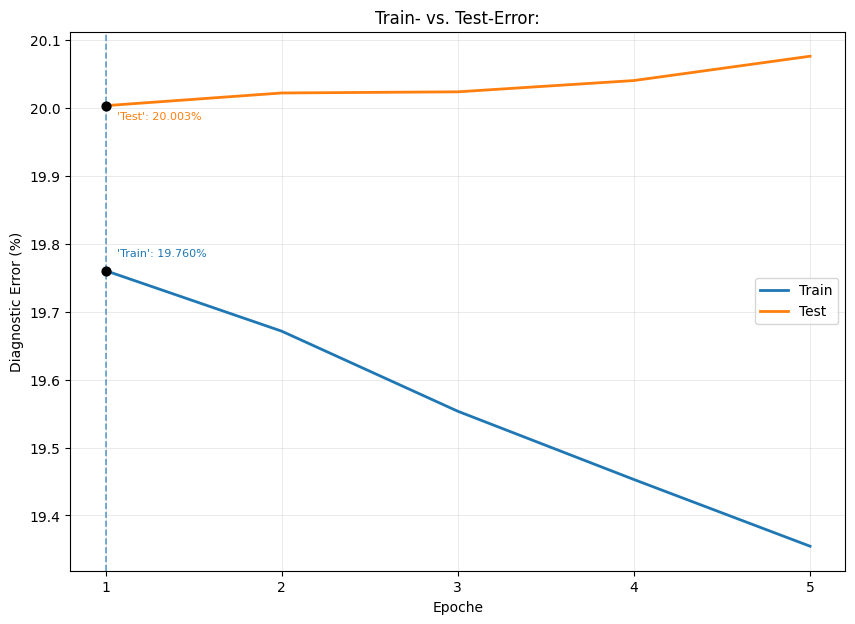

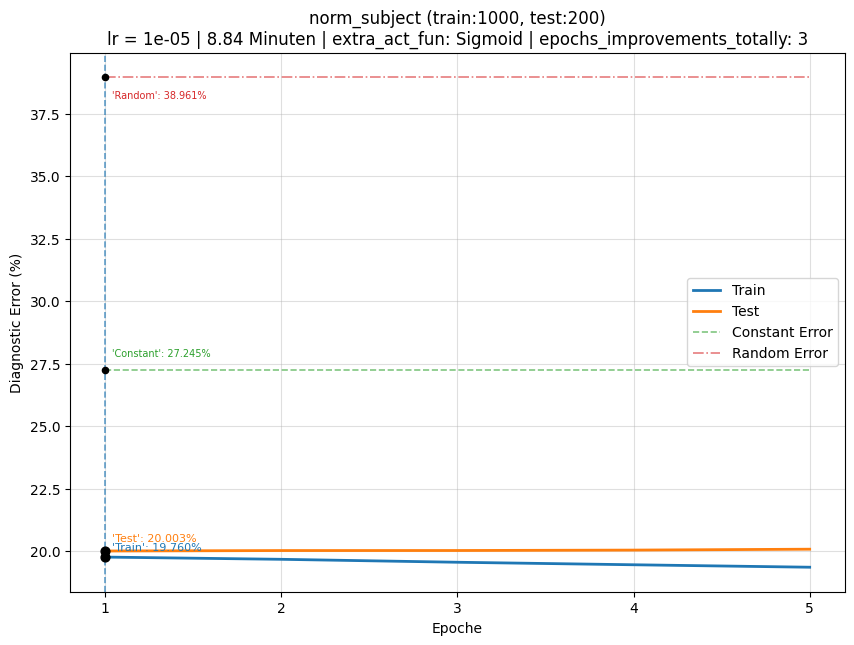

In [35]:

print(f"\n\n Diagonal-Train-Error: {np.float64(diag_train_error)}\n")
print(f" Diagonal-Test-Error: {np.float64(diag_test_error)}\n\n")

print(f" Diagonal-Train-Error-Max: {np.max(diag_train_error)} \t Diagonal-Train-Error-Min: {np.min(diag_train_error)}\t")
# print(f" Diagonal-Train-Error-Ave: {np.mean(diag_train_error)}\n")

print(f" Diagonal-Test-Error-Max: {np.max(diag_test_error)}\t Diagonal-Test-Error-Min: {np.min(diag_test_error)}\t max_needed_epochs: {e+2}\n\n")
# print(f" Diagonal-Test-Error-Ave: {np.mean(diag_test_error)}\n")


if globals().get("bas_const_err") is None:
    bas_const_err = 27.245

if globals().get("bas_rand_err") is None:
    bas_rand_err = 38.961


# Curven:

# Minimum Test Error bestimmen
min_test_error = min(diag_test_error)
min_test_epoch = diag_test_error.index(min_test_error) + 1

# Die vier Werte an dieser Epoch
train_at_min = diag_train_error[min_test_epoch - 1]
test_at_min = diag_test_error[min_test_epoch - 1]
const_at_min = bas_const_err
rand_at_min = bas_rand_err

# Die Farbe
train_color = "tab:blue"
test_color = "tab:orange"
const_color = "tab:green"
rand_color = "tab:red"
point_color = "black"

# Epochs beginnen bei 1
epochs = range(1, len(diag_test_error) + 1)
# epochs = range(0, len(diag_test_error) + 1)

plt.figure(figsize=(10, 7))

# Train Error
plt.plot(epochs, diag_train_error, label="Train", linewidth=2, color=train_color)


# Test Error
plt.plot(epochs, diag_test_error, label="Test", linewidth=2, color=test_color)


# Vertikale Linie durch alle vier Kurven
plt.axvline(
    x=min_test_epoch,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7,
    # label=f"Min Test Error (Epoch {min_test_epoch})"
)

# Punkt beim Minimum des Test Errors
plt.scatter(
    min_test_epoch,
    min_test_error,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Min Test Error ({min_test_error:.2f}%)"
)

plt.scatter(
    min_test_epoch,
    train_at_min,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Train at min_Test_Error ({train_at_min_test:.2f}%)"
)

# Werte an der vertikalen Linie anzeigen
plt.annotate(
    f"'Train': {train_at_min:.3f}%",
    xy=(min_test_epoch, train_at_min),
    xytext=(8, 10),
    textcoords="offset points",
    color=train_color,
    fontsize=8
)

plt.annotate(
    f"'Test': {test_at_min:.3f}%",
    xy=(min_test_epoch, test_at_min),
    xytext=(8, -10),
    textcoords="offset points",
    color=test_color,
    fontsize=8,
)


plt.title("Train- vs. Test-Error:")
plt.xlabel("Epoche")
plt.ylabel("Diagnostic Error (%)")

plt.xticks(epochs)

plt.grid(True, alpha=0.3, linewidth=0.6)
plt.legend()



# ===================================================
# =============== all 4 Diagrams ====================
# ===================================================


plt.figure(figsize=(10, 7))


# Train Error
plt.plot(
    epochs,
    diag_train_error,
    label="Train",
    linewidth=2,
    color=train_color
)


# Test Error
plt.plot(
    epochs,
    diag_test_error,
    label="Test",
    linewidth=2,
    color=test_color
)


# Constant Baseline
plt.plot(
    epochs,
    [bas_const_err] * len(epochs),
    label="Constant Error",
    linestyle="--",
    linewidth=1.2,
    alpha=0.6,
    color=const_color
)


# Random Baseline
plt.plot(
    epochs,
    [bas_rand_err] * len(epochs),
    label="Random Error",
    linestyle="-.",
    linewidth=1.2,
    alpha=0.6,
    color=rand_color
)



print(f"\nMinimum Test Error:")
print(f"Epoch:           {min_test_epoch}")
print(f"Test Error:      {test_at_min:.4f}%")
print(f"Train Error:     {train_at_min:.4f}%")
print(f"Constant Error:  {bas_const_err:.4f}%")
print(f"Random Error:    {bas_rand_err:.4f}%\n")


# Punkt beim Minimum des Test Errors
plt.scatter(
    min_test_epoch,
    min_test_error,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Min Test Error ({min_test_error:.2f}%)"
)

plt.scatter(
    min_test_epoch,
    train_at_min,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Train at min_Test_Error ({train_at_min_test:.2f}%)"
)

plt.scatter(
    min_test_epoch,
    const_at_min,
    s=20,
    zorder=4,
    color=point_color
)

plt.scatter(
    min_test_epoch,
    rand_at_min,
    s=20,
    zorder=4,
    color=point_color
)


# Vertikale Linie durch alle vier Kurven
plt.axvline(
    x=min_test_epoch,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7,
    # label=f"Min Test Error (Epoch {min_test_epoch})"
)

# Werte an der vertikalen Linie anzeigen
plt.annotate(
    f"'Train': {train_at_min:.3f}%",
    xy=(min_test_epoch, train_at_min),
    xytext=(5, 5),
    textcoords="offset points",
    color=train_color,
    fontsize=8
)

plt.annotate(
    f"'Test': {test_at_min:.3f}%",
    xy=(min_test_epoch, test_at_min),
    xytext=(5, 7),
    textcoords="offset points",
    color=test_color,
    fontsize=8
)

plt.annotate(
    f"'Constant': {const_at_min:.3f}%",
    xy=(min_test_epoch, const_at_min),
    xytext=(5, 10),
    textcoords="offset points",
    color=const_color,
    fontsize=7
)

plt.annotate(
    f"'Random': {rand_at_min:.3f}%",
    xy=(min_test_epoch, rand_at_min),
    xytext=(5, -15),
    textcoords="offset points",
    color=rand_color,
    fontsize=7
)

# Titel
plt.title(
    f"{def_dataset} "
    f"(train:{def_dataset_size[0]}, test:{def_dataset_size[1]})\n"
    f"lr = {learning_rate} | "
    f"{elapsed_running_time / 60:.2f} Minuten | "
    f"extra_act_fun: {active_func} | "
    f"epochs_improvements_totally: {e + 2}"
)
# plt.title(f"{def_dataset}((train:{def_dataset_size[0]}, test:{def_dataset_size[1]})) \n" 
#           f" lr = {learning_rate} | {elapsed_running_time/60:.2f} Minuten | extra_act_fun: {active_func} | epochs_imporovments_totally: {e+2}"
# )

plt.xlabel("Epoche")
plt.ylabel("Diagnostic Error (%)")

plt.xticks(epochs)

# plt.xticks(range(1, len(epochs) + 1, 1))
# plt.yticks(range(0, 51, 5))

plt.grid(True, alpha=0.4)
plt.legend()

# Ordner erstellen (falls er noch nicht existiert)
os.makedirs("./results", exist_ok=True)

# Diagramm speichern
plt.savefig(
    f"results/diag_error_{def_dataset}_{learning_rate}_{def_dataset_size[0]}_{def_dataset_size[1]}_a.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Compare : 
lr (1e-4 vs. 1e-5 vs. 1e-6) | 

datasets: (random_split vs. norm_subject_split) | 

train_size (1% vs 10%) 

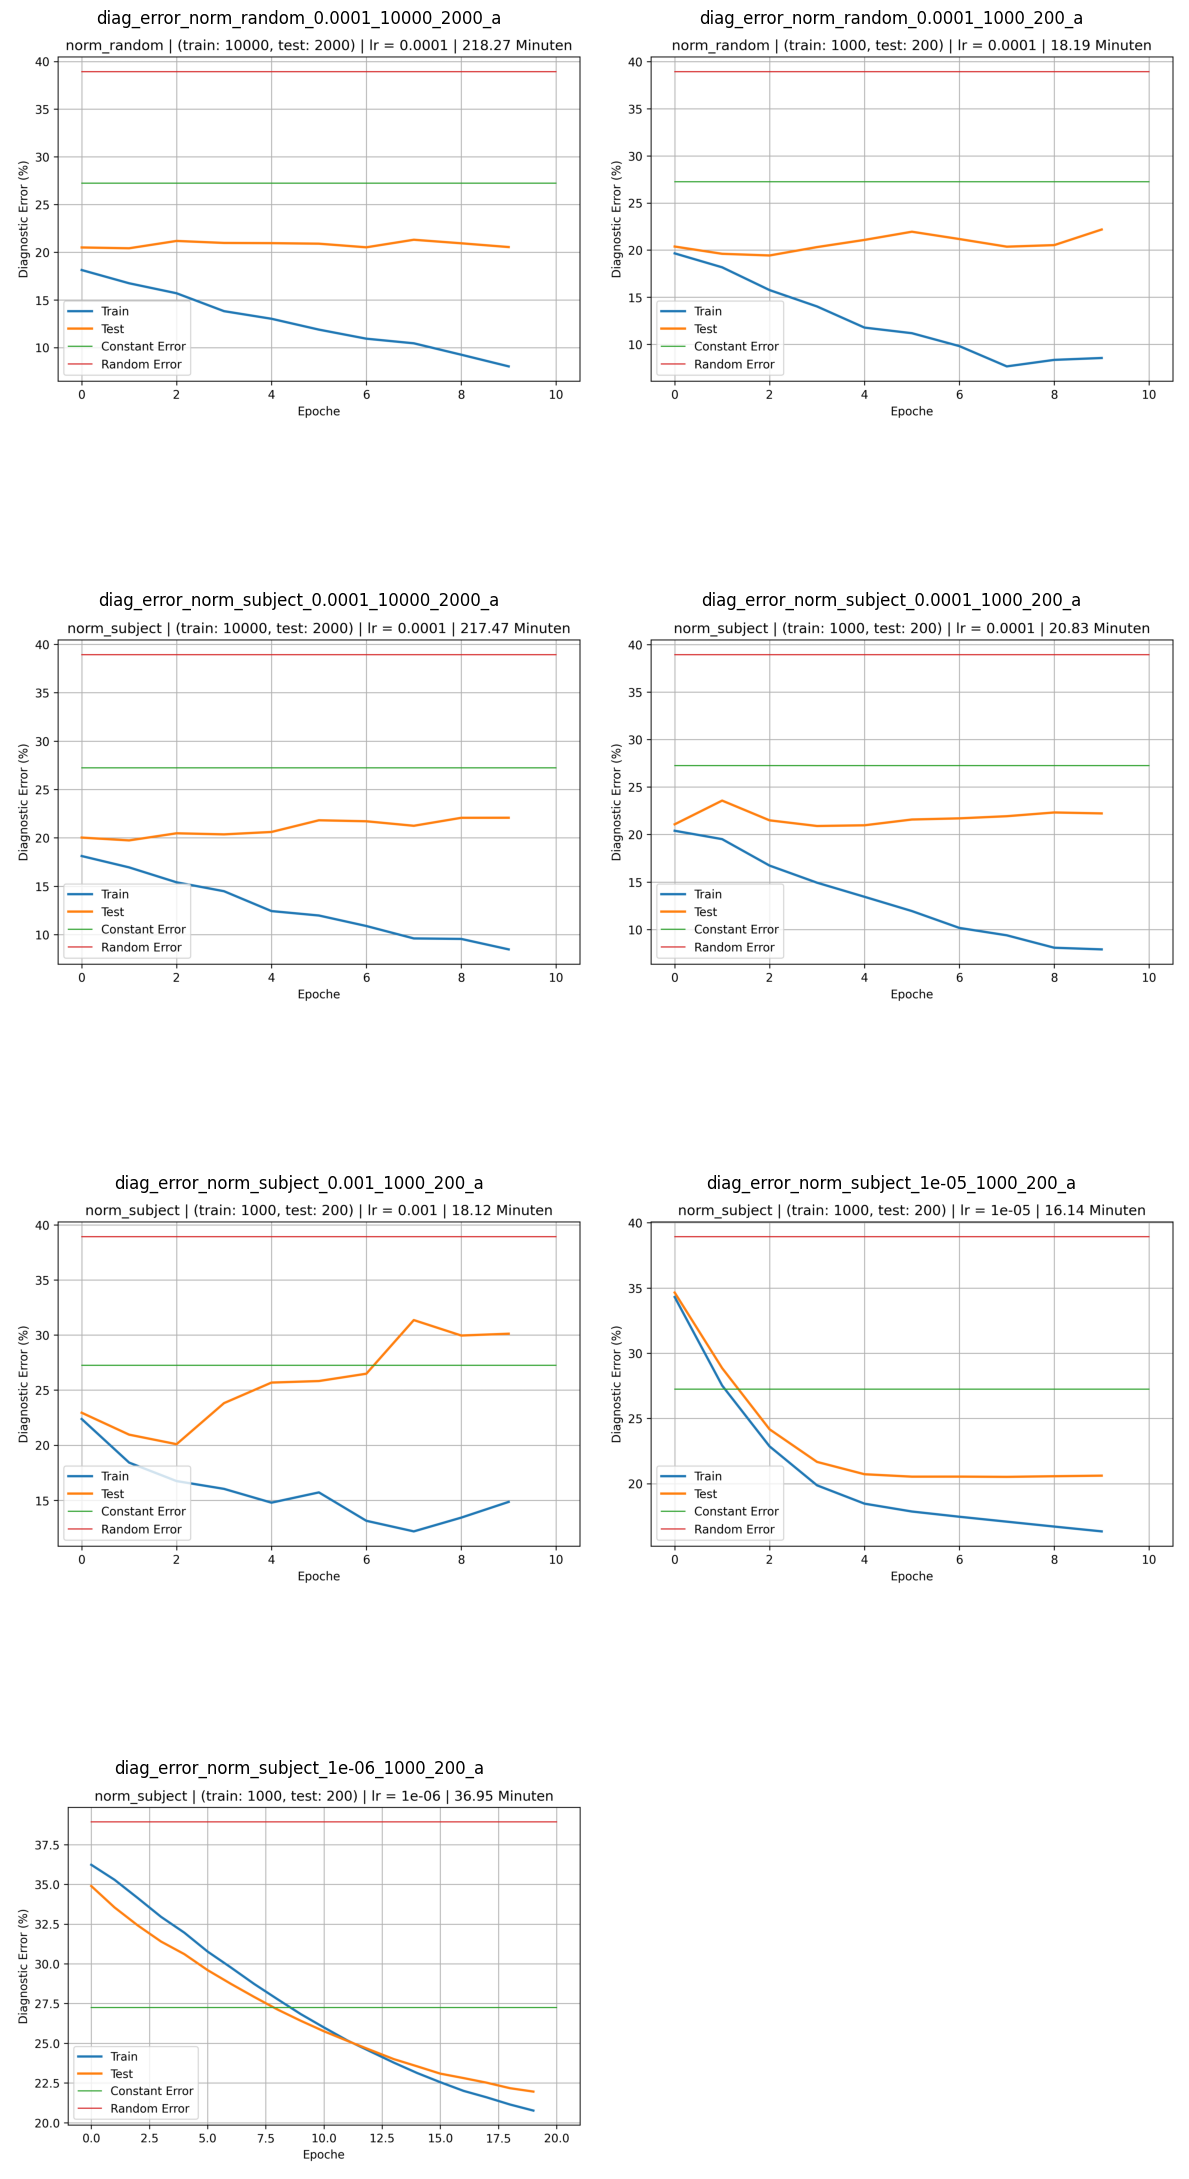

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

result_path = Path("./results")

images = sorted(result_path.glob("*.png"))

cols = 2
rows = (len(images) + cols - 1) // cols

plt.figure(figsize=(12, 6 * rows))

for i, img_path in enumerate(images):

    img = mpimg.imread(img_path)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.stem)

plt.tight_layout()
plt.show()

# ============== Evaluation ============= #

In [13]:
# ---------- Evaluation ----------

saved_model_name = "models/ResNet_try_optim-model_norm_subject_1000-200.path"
saved_model = "./models/best-model_ResNet_Sigmoid.path"

checkpoint = torch.load(
    saved_model,
    map_location=device
)

model.load_state_dict(checkpoint)

model.to(device)

model.eval()


print(f"Test:\n")
test_mae, test_rmse, test_diag_pct = diagonal_errors(model, test_loader, device)

print(
        f"test_diag_error={test_diag_pct:.4f}% "
    )


targets, predictions, errors = evaluate_model(
    model,
    test_loader,
    device
)

Test:

MAE : 0.2366 	 RMSE: 0.2847 
Diagonal-Error %: 20.1280 %
test_diag_error=20.1280% 


## Loss 1:

# loss 1, try 1:


# loss 1, try 2:


# loss 1, try 3:


# loss 1, try 4:


# loss 1, try 5:


## Loss 2:

# loss 2, try 1:
MAE : 0.2366 	 RMSE: 0.2847 
Diagonal-Error %: 20.1280 %
test_diag_error=20.1280% 

# loss 2, try 2:


# loss 2, try 3:


# loss 2, try 4:


# loss 2, try 5:


In [14]:
import pandas as pd


results_df = pd.DataFrame({
    "gt_x": targets[:, 0],
    "gt_y": targets[:, 1],
    "pred_x": predictions[:, 0],
    "pred_y": predictions[:, 1]
})


results_df.to_csv(
    "results/baseline_predictions_loss2.csv",
    index=False
)


In [38]:
# Test:
print(results_df.head(10))

print(f"\n Anzahl Ergebnisse: {len(results_df)}\n\n")

print(results_df.shape)


       gt_x      gt_y    pred_x    pred_y
0  0.609727  0.246337  0.479229  0.501485
1  0.609727  0.246337  0.478659  0.507570
2  0.609727  0.246337  0.474599  0.505390
3  0.609727  0.246337  0.479476  0.499415
4  0.113634  0.162799  0.477582  0.501991
5  0.113634  0.162799  0.478623  0.503317
6  0.113634  0.162799  0.479308  0.505337
7  0.113634  0.162799  0.474226  0.502242
8  0.113634  0.162799  0.479581  0.504091
9  0.389503  0.616551  0.477245  0.502086

 Anzahl Ergebnisse: 200


(200, 4)


# ---------- Visualization ----------

In [39]:
import numpy as np
from scipy import stats

import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import Ellipse


In [40]:
class GazeVisualizer:

    def plot_ground_truth(self, targets):
        
        plt.figure(figsize=(6,6))

        plt.scatter(
            targets[:,0],
            targets[:,1],
            s=8
        )
        
        plt.title("Ground Truth")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.grid()
        plt.show()
        

    def plot_predictions(self, predictions):
        
        plt.figure(figsize=(6,6))

        plt.scatter(
            predictions[:,0],
            predictions[:,1],
            s=8
        )
        
        plt.title("Prediction")
        plt.grid()
        plt.show()

    
    def plot_comparison(self, predictions, targets):
        
        plt.figure(figsize=(7,7))
        
        plt.scatter(
            targets[:,0],
            targets[:,1],
            color="red",
            s=15,
            label="Ground Truth"
        )
        
        plt.scatter(
            predictions[:,0],
            predictions[:,1],
            color="blue",
            s=15,
            label="Prediction"
        )
        
        for i in range(len(targets)):
            plt.plot(
                [targets[i,0], predictions[i,0]],
                [targets[i,1], predictions[i,1]],
                color="gray",
                alpha=0.2
            )
        
        plt.legend()
        plt.grid()
        plt.show()



In [41]:
def plot_confidence_ellipse(mu, cov, confidence, ax, **kwargs):

    # Chi-Square quantile für 2 Freiheitsgrade
    c = -2 * np.log(1 - confidence)

    # Eigenwerte und Eigenvektoren
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    # Größten Eigenwert zuerst
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    # Breite und Höhe der Ellipse
    width, height = 2 * np.sqrt(c * eigenvalues)

    # Winkel des größten Eigenvektors
    angle = np.degrees(
        np.arctan2(
            eigenvectors[1, 0],
            eigenvectors[0, 0]
        )
    )

    ellipse = Ellipse(
        xy=mu,
        width=width,
        height=height,
        angle=angle,
        fill=False,
        **kwargs
    )

    ax.add_patch(ellipse)

    return ellipse

In [42]:
def confidence_interval(data, confidence=0.95):

    data = np.asarray(data)

    n = len(data)

    mean = np.mean(data)
    std = np.std(data, ddof=1)

    standard_error = std / np.sqrt(n)

    t_value = stats.t.ppf(
        (1 + confidence) / 2,
        df=n - 1
    )

    margin = t_value * standard_error

    lower = mean - margin
    upper = mean + margin

    return mean, lower, upper

In [43]:
try:
        df = pd.read_csv('results/baseline_predictions2.csv')

        
except Exception as e:
    print(f"Error loading CSV file: {e}")

gt_x, gt_y = df[['gt_x']].to_numpy(), df[['gt_y']].to_numpy()
pred_x, pred_y = df[['pred_x']].to_numpy(), df[['pred_y']].to_numpy()

mean_x, lower_x, upper_x = confidence_interval(gt_x)
mean_y, lower_y, upper_y = confidence_interval(gt_y)

mean_px, lower_px, upper_px = confidence_interval(pred_x)
mean_py, lower_py, upper_py = confidence_interval(pred_y)

## Output:
# Grund Truth:
print(f"\nX Mean: {mean_x:.4f}")
print(f"X 95% CI: [{lower_x:.4f}, {upper_x:.4f}]")

print(f"\nY Mean: {mean_y:.4f}")
print(f"Y 95% CI: [{lower_y:.4f}, {upper_y:.4f}]\n")

# Predictions:
print(f"\nPred_X Mean: {mean_px:.4f}")
print(f"Pred_X 95% CI: [{lower_px:.4f}, {upper_px:.4f}]")

print(f"\nPred_Y Mean: {mean_py:.4f}")
print(f"Pred_Y 95% CI: [{lower_py:.4f}, {upper_py:.4f}]\n")


X Mean: 0.4483
X 95% CI: [0.4072, 0.4894]

Y Mean: 0.4730
Y 95% CI: [0.4355, 0.5105]


Pred_X Mean: 0.4790
Pred_X 95% CI: [0.4786, 0.4794]

Pred_Y Mean: 0.5035
Pred_Y 95% CI: [0.5030, 0.5041]



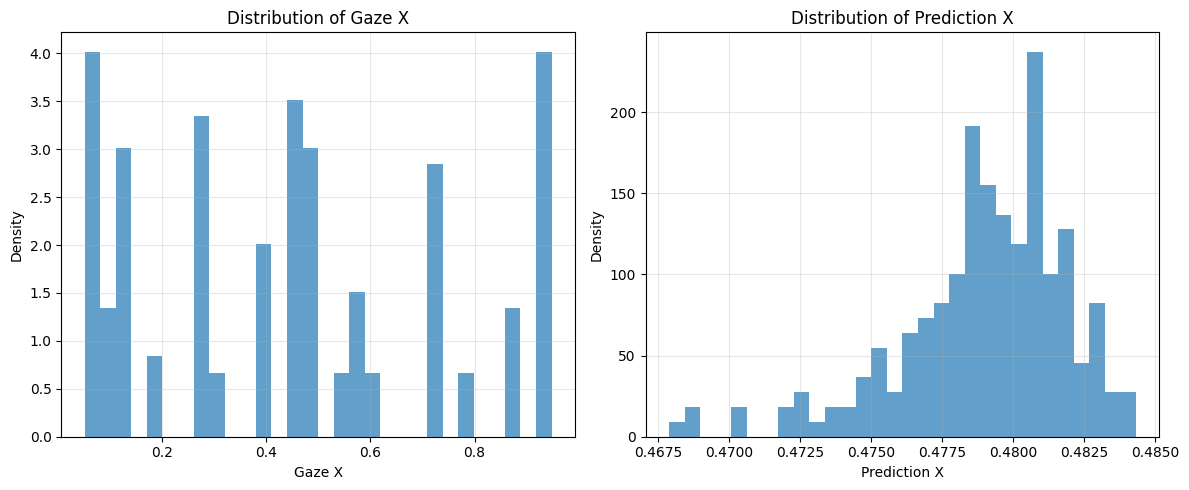

In [44]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 5)
)

# -------------------------
# Ground Truth X
# -------------------------
ax1.hist(
    gt_x,
    bins=30,
    density=True,
    alpha=0.7
)

ax1.set_xlabel("Gaze X")
ax1.set_ylabel("Density")
ax1.set_title("Distribution of Gaze X")
ax1.grid(True, alpha=0.3)


# -------------------------
# Prediction X
# -------------------------
ax2.hist(
    pred_x,
    bins=30,
    density=True,
    alpha=0.7
)

ax2.set_xlabel("Prediction X")
ax2.set_ylabel("Density")
ax2.set_title("Distribution of Prediction X")
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

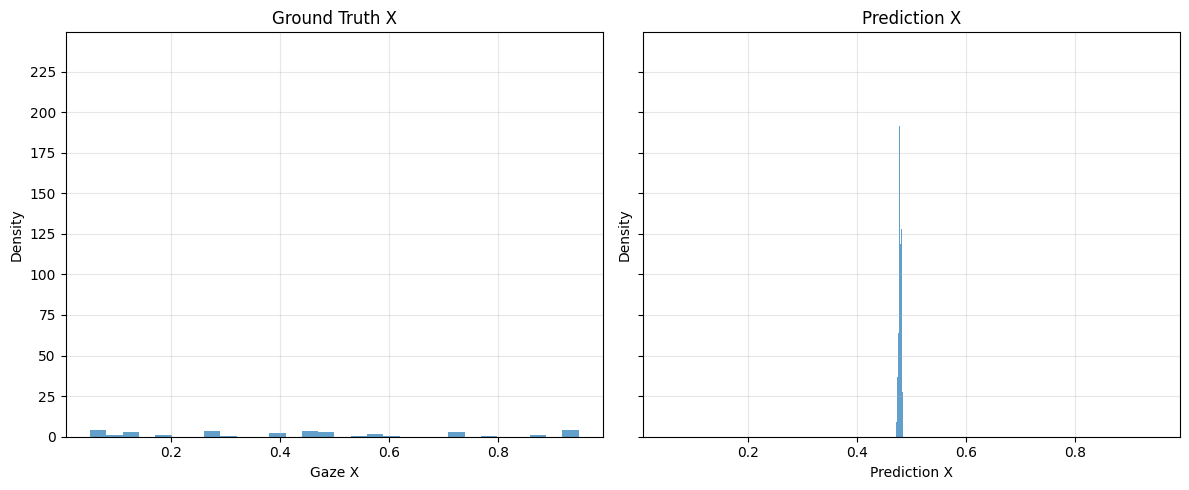

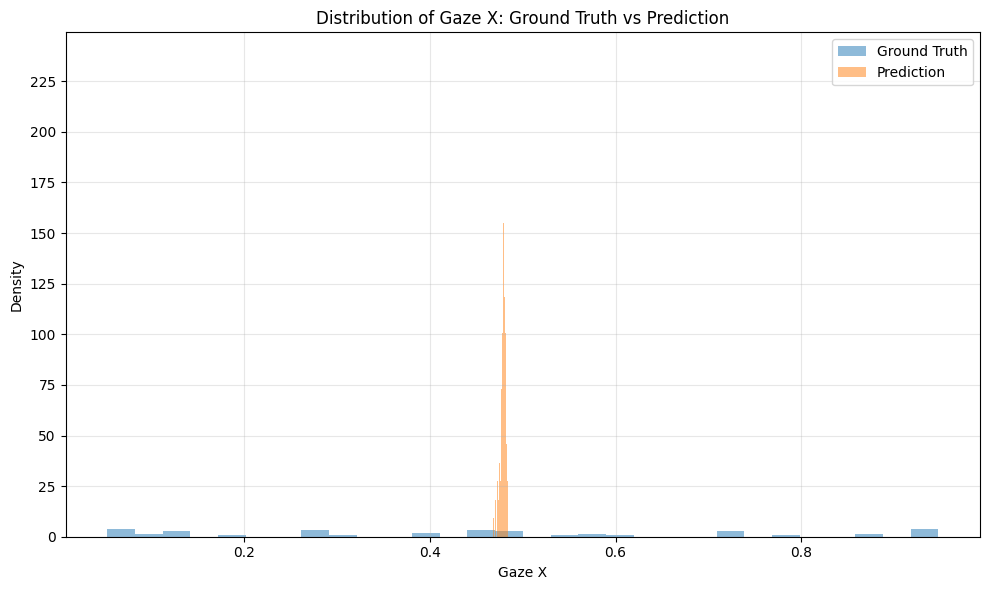

In [50]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharex=True,
    sharey=True
)

# Ground Truth
ax1.hist(
    gt_x,
    bins=30,
    density=True,
    alpha=0.7
)

ax1.set_xlabel("Gaze X")
ax1.set_ylabel("Density")
ax1.set_title("Ground Truth X")
ax1.grid(True, alpha=0.3)


# Prediction
ax2.hist(
    pred_x,
    bins=30,
    density=True,
    alpha=0.7
)

ax2.set_xlabel("Prediction X")
ax2.set_ylabel("Density")
ax2.set_title("Prediction X")
ax2.grid(True, alpha=0.3)

plt.yticks(range(0, 250, 25))
plt.tight_layout()
plt.show()




plt.figure(figsize=(10, 6))

plt.hist(
    gt_x,
    bins=30,
    density=True,
    alpha=0.5,
    label="Ground Truth"
)

plt.hist(
    pred_x,
    bins=30,
    density=True,
    alpha=0.5,
    label="Prediction"
)

plt.xlabel("Gaze X")
plt.ylabel("Density")
plt.title("Distribution of Gaze X: Ground Truth vs Prediction")

plt.legend()
plt.grid(True, alpha=0.3)

plt.yticks(range(0, 250, 25))
plt.tight_layout()
plt.show()

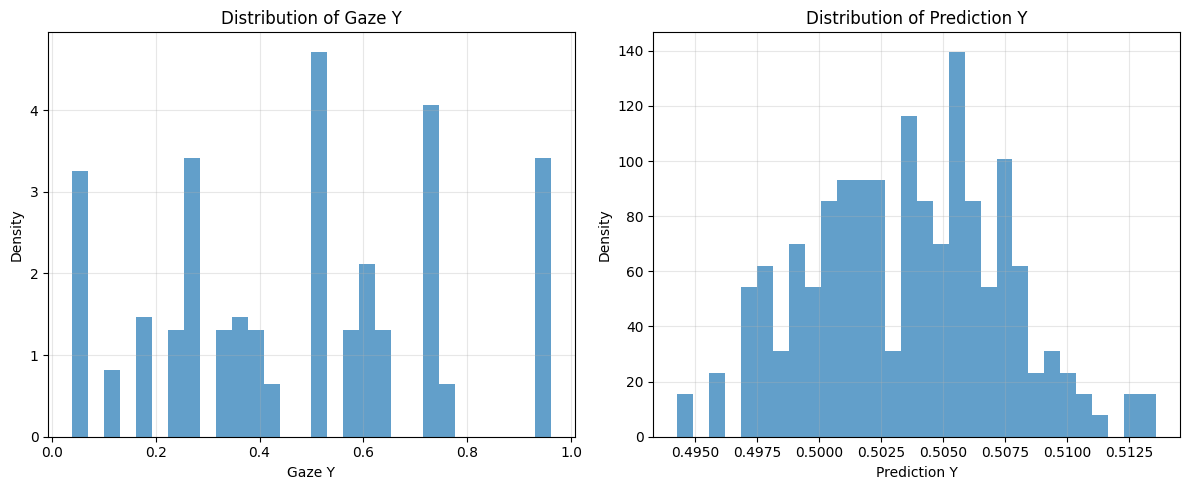

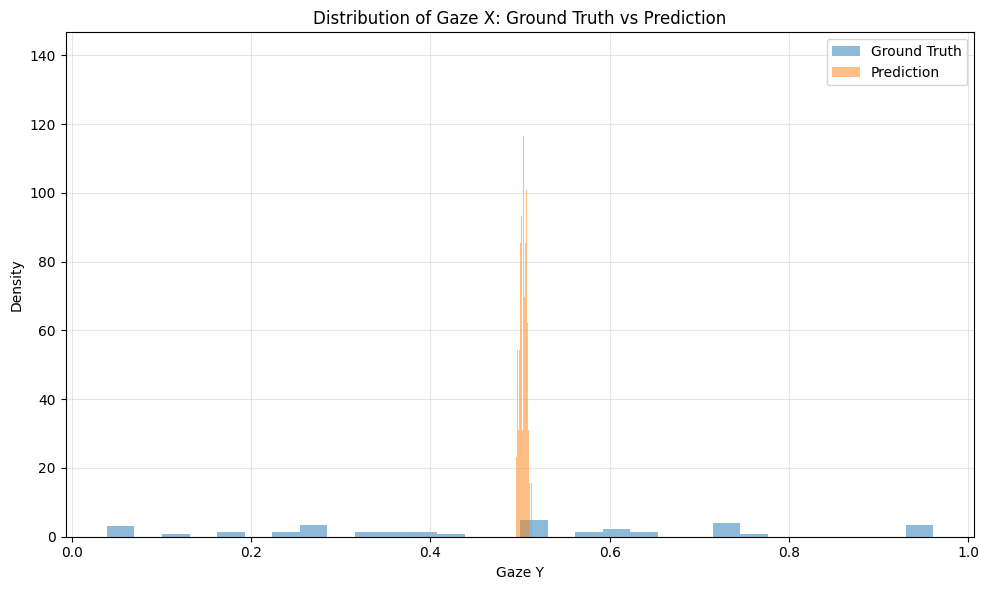

In [51]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 5)
)

# -------------------------
# Ground Truth Y
# -------------------------
ax1.hist(
    gt_y,
    bins=30,
    density=True,
    alpha=0.7
)

ax1.set_xlabel("Gaze Y")
ax1.set_ylabel("Density")
ax1.set_title("Distribution of Gaze Y")
ax1.grid(True, alpha=0.3)


# -------------------------
# Prediction Y
# -------------------------
ax2.hist(
    pred_y,
    bins=30,
    density=True,
    alpha=0.7
)

ax2.set_xlabel("Prediction Y")
ax2.set_ylabel("Density")
ax2.set_title("Distribution of Prediction Y")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))

plt.hist(
    gt_y,
    bins=30,
    density=True,
    alpha=0.5,
    label="Ground Truth"
)

plt.hist(
    pred_y,
    bins=30,
    density=True,
    alpha=0.5,
    label="Prediction"
)

plt.xlabel("Gaze Y")
plt.ylabel("Density")
plt.title("Distribution of Gaze X: Ground Truth vs Prediction")

plt.legend()
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

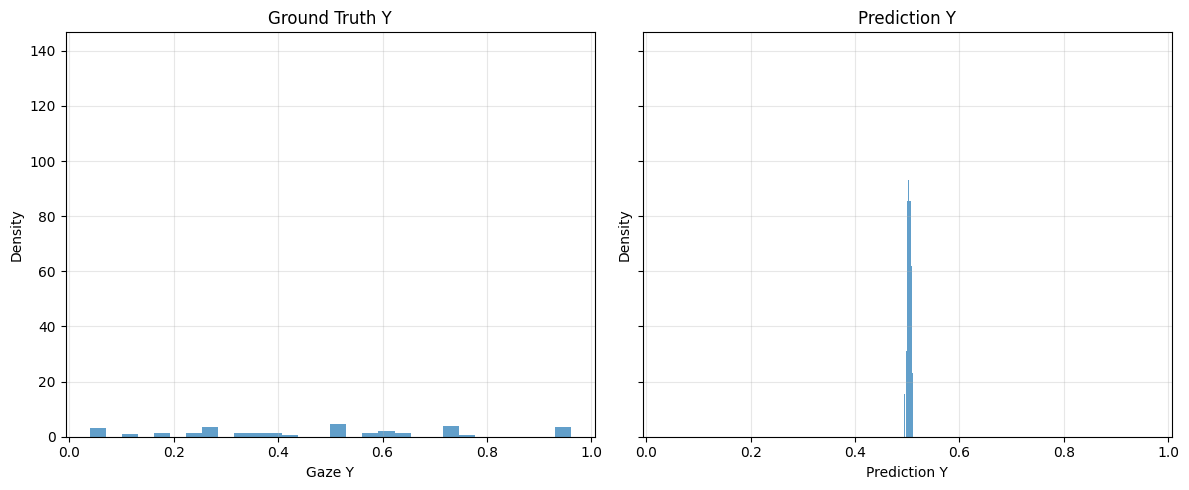

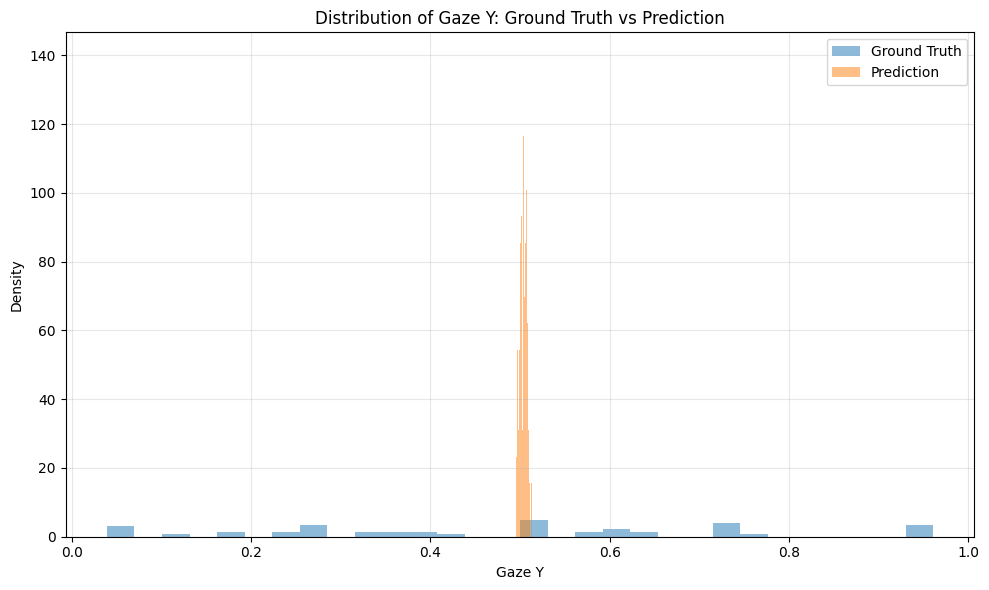

In [59]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharex=True,
    sharey=True
)

# Ground Truth
ax1.hist(
    gt_y,
    bins=30,
    density=True,
    alpha=0.7
)

ax1.set_xlabel("Gaze Y")
ax1.set_ylabel("Density")
ax1.set_title("Ground Truth Y")
ax1.grid(True, alpha=0.3)


# Prediction
ax2.hist(
    pred_y,
    bins=30,
    density=True,
    alpha=0.7
)

ax2.set_xlabel("Prediction Y")
ax2.set_ylabel("Density")
ax2.set_title("Prediction Y")
ax2.grid(True, alpha=0.3)

plt.yticks(range(0, 160, 20))
plt.tight_layout()
plt.show()




plt.figure(figsize=(10, 6))

plt.hist(
    gt_y,
    bins=30,
    density=True,
    alpha=0.5,
    label="Ground Truth"
)

plt.hist(
    pred_y,
    bins=30,
    density=True,
    alpha=0.5,
    label="Prediction"
)

plt.xlabel("Gaze Y")
plt.ylabel("Density")
plt.title("Distribution of Gaze Y: Ground Truth vs Prediction")

plt.legend()
plt.grid(True, alpha=0.3)


plt.yticks(range(0, 160, 20))
plt.tight_layout()
plt.show()


Min_gt_X: [0.05208333] 	 Max_gt_X: [0.9479167]
Min_gt_Y:[0.0390625] 	 Max_gt_Y: [0.9609375]


len(points_gt): 200
len(points_prd): 200


Mean Ground-Truth:
	 X-mean: 0.448291 	 Y-mean: 0.472981 

Covariance - Ground Truth:
	 X-Cov: [0.087038, 0.006601]

	 Y-Cov: [0.006601, 0.072284]


Mean Predictions:
	 X-mean: 0.478976 	 Y-mean: 0.503518 

Covariance - Prediction:
	 X-Cov: [0.000009, 0.000004]

	 Y-Cov: [0.000004, 0.000015]


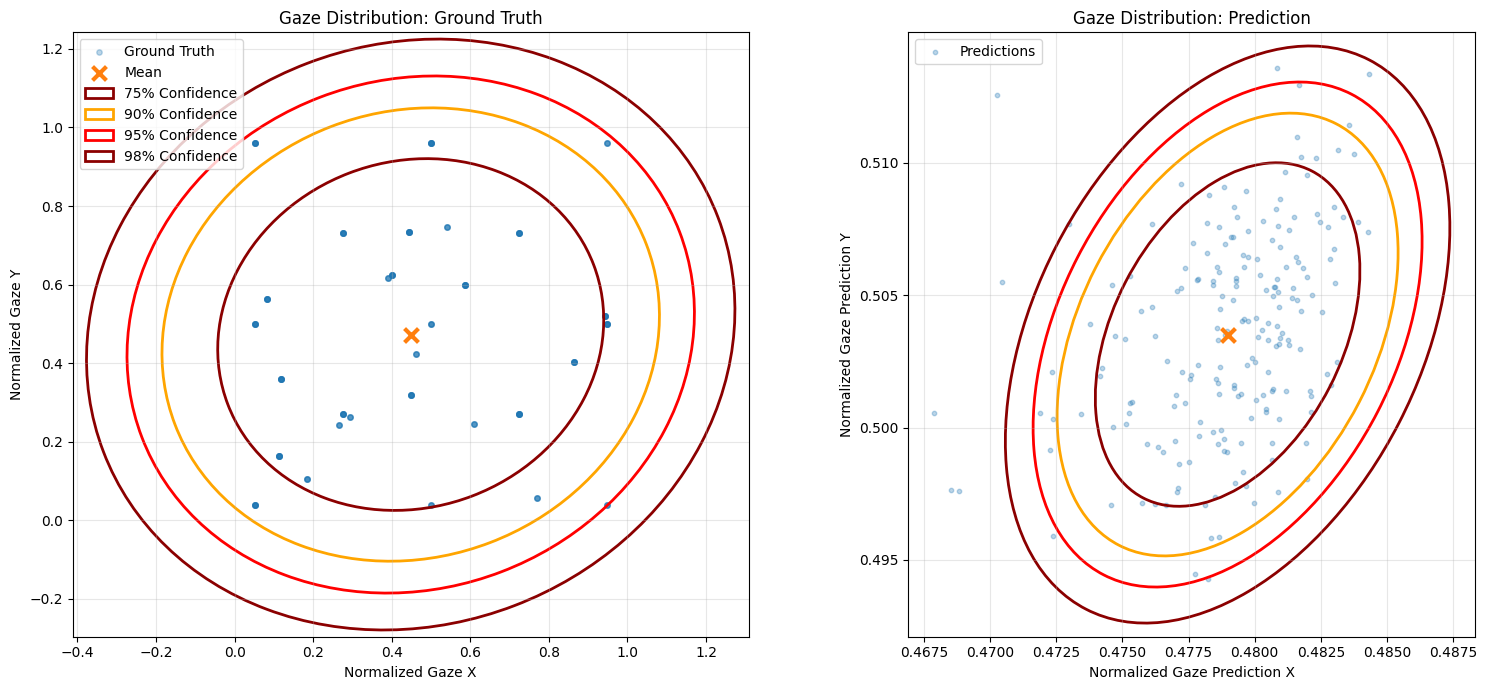

In [60]:

# df = pd.read_csv("results/baseline_predictions.csv")

# gt_x = df["gt_x"].to_numpy()
# gt_y = df["gt_y"].to_numpy()
# pred_x = df["pred_x"].to_numpy()
# pred_y = df["pred_y"].to_numpy()

print(f"\nMin_gt_X: {min(gt_x)} \t Max_gt_X: {max(gt_x)}\n"
      f"Min_gt_Y:{min(gt_y)} \t Max_gt_Y: {max(gt_y)}\n\n")

points_gt = np.column_stack((gt_x, gt_y))
print(f"len(points_gt): {len(points_gt)}")

points_prd = np.column_stack((pred_x, pred_y))
print(f"len(points_prd): {len(points_prd)}")


mu_gt = np.mean(points_gt, axis=0)
cov_gt = np.cov(points_gt, rowvar=False)

mu_prd = np.mean(points_prd, axis=0)
cov_prd = np.cov(points_prd, rowvar=False)

print(f"\n\nMean Ground-Truth:\n\t X-mean: {mu_gt[0]:.6f} \t Y-mean: {mu_gt[1]:.6f} " 
      f"\n\nCovariance - Ground Truth:\n\t X-Cov: [{cov_gt[0][0]:.6f}, {cov_gt[0][1]:.6f}]" 
      f"\n\n\t Y-Cov: [{cov_gt[1][0]:.6f}, {cov_gt[1][1]:.6f}]")


print(f"\n\nMean Predictions:\n\t X-mean: {mu_prd[0]:.6f} \t Y-mean: {mu_prd[1]:.6f} " 
      f"\n\nCovariance - Prediction:\n\t X-Cov: [{cov_prd[0][0]:.6f}, {cov_prd[0][1]:.6f}]" 
      f"\n\n\t Y-Cov: [{cov_prd[1][0]:.6f}, {cov_prd[1][1]:.6f}]")


# =============================================================
# =================== PLOT ====================================
# =============================================================

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(16, 7)
)

# =============================================================
# ================= Ground Truth ==============================
# =============================================================

# Datenpunkte
ax1.scatter(
    gt_x,
    gt_y,
    s=15,
    alpha=0.3,
    label="Ground Truth"
)

# Mean
ax1.scatter(
    mu_gt[0],
    mu_gt[1],
    marker="x",
    s=100,
    linewidths=3,
    label="Mean"
)

# 75% Confidence
plot_confidence_ellipse(
    mu_gt,
    cov_gt,
    0.75,
    ax1,
    edgecolor="darkred",
    linewidth=2,
    label="75% Confidence"
)

# 90% Confidence
plot_confidence_ellipse(
    mu_gt,
    cov_gt,
    0.90,
    ax1,
    edgecolor="orange",
    linewidth=2,
    label="90% Confidence"
)

# 95% Confidence
plot_confidence_ellipse(
    mu_gt,
    cov_gt,
    0.95,
    ax1,
    edgecolor="red",
    linewidth=2,
    label="95% Confidence"
)

# 98% Confidence
plot_confidence_ellipse(
    mu_gt,
    cov_gt,
    0.98,
    ax1,
    edgecolor="darkred",
    linewidth=2,
    label="98% Confidence"
)


ax1.set_xlabel("Normalized Gaze X")
ax1.set_ylabel("Normalized Gaze Y")

ax1.set_title(
    "Gaze Distribution: Ground Truth"
)

ax1.grid(True, alpha=0.3)
ax1.legend()

ax1.set_aspect("equal")



# =============================================================
# ================= Prediction ================================
# =============================================================

# Datenpunkte
ax2.scatter(
    pred_x,
    pred_y,
    s=10,
    alpha=0.3,
    label="Predictions"
)

# Mean
ax2.scatter(
    mu_prd[0],
    mu_prd[1],
    marker="x",
    s=100,
    linewidths=3,
    # label="Mean"
)

# 75% Confidence
plot_confidence_ellipse(
    mu_prd,
    cov_prd,
    0.75,
    ax2,
    edgecolor="darkred",
    linewidth=2,
    # label="75% Confidence"
)

# 90% Confidence
plot_confidence_ellipse(
    mu_prd,
    cov_prd,
    0.90,
    ax2,
    edgecolor="orange",
    linewidth=2,
    # label="90% Confidence"
)

# 95% Confidence
plot_confidence_ellipse(
    mu_prd,
    cov_prd,
    0.95,
    ax2,
    edgecolor="red",
    linewidth=2,
    # label="95% Confidence"
)

# 98% Confidence
plot_confidence_ellipse(
    mu_prd,
    cov_prd,
    0.98,
    ax2,
    edgecolor="darkred",
    linewidth=2,
    # label="98% Confidence"
)

# 99.995% Confidence
# plot_confidence_ellipse(
#     mu_prd,
#     cov_prd,
#     0.99995,
#     ax2,
#     edgecolor="yellow",
#     linewidth=2,
#     label="99.995% Confidence"
# )


ax2.set_xlabel("Normalized Gaze Prediction X")
ax2.set_ylabel("Normalized Gaze Prediction Y")

ax2.set_title(
    "Gaze Distribution: Prediction"
)

ax2.grid(True, alpha=0.3)
ax2.legend()

ax2.set_aspect("equal")


# =============================================================
# =================== Gemeinsames Layout ======================
# =============================================================

plt.tight_layout()
plt.show()



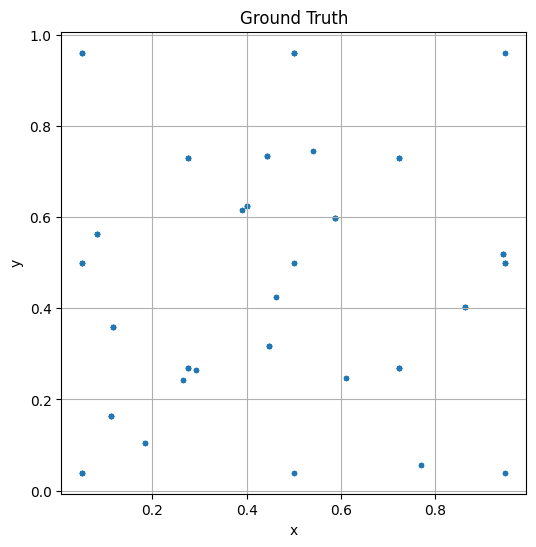

In [61]:

vis = GazeVisualizer()

vis.plot_ground_truth(targets)



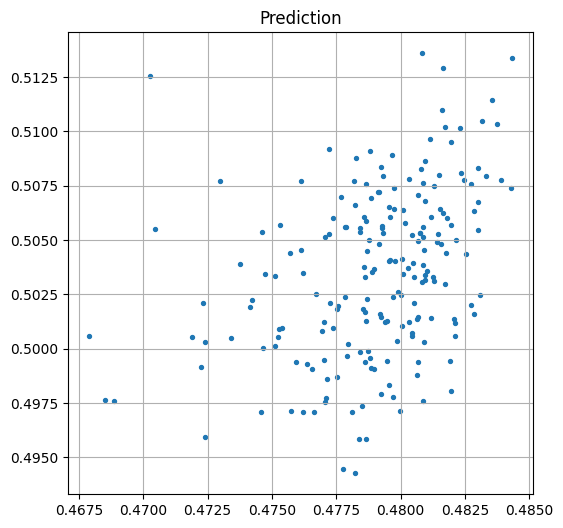

In [62]:
vis.plot_predictions(predictions)


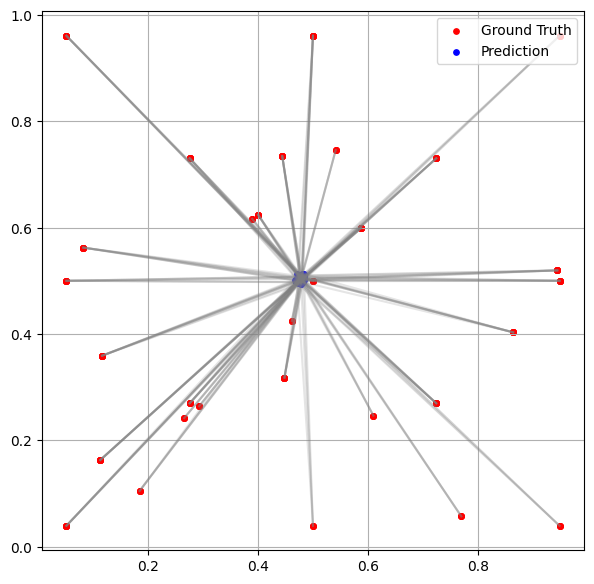

In [63]:
vis.plot_comparison(predictions, targets)

